In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))  

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import load_raw_data, get_basic_info
from src.utils.config import CATEGORY_TARGET, PRIORITY_TARGET, TEXT_COLUMN

# Makes all plots look clean and consistent
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
df = load_raw_data()
get_basic_info(df)

[2026-04-02 04:22:55] INFO — src.data.loader — Loading dataset from E:\Future ml projects\FUTURE_ML_02\data\raw\customer_support_tickets.csv
[2026-04-02 04:22:56] INFO — src.data.loader — Loaded 8469 rows and 17 columns
[2026-04-02 04:22:56] INFO — src.data.loader — === DATASET SHAPE ===
[2026-04-02 04:22:56] INFO — src.data.loader — Rows: 8469, Columns: 17
[2026-04-02 04:22:56] INFO — src.data.loader — === COLUMN NAMES ===
[2026-04-02 04:22:56] INFO — src.data.loader —   - Ticket ID
[2026-04-02 04:22:56] INFO — src.data.loader —   - Customer Name
[2026-04-02 04:22:56] INFO — src.data.loader —   - Customer Email
[2026-04-02 04:22:56] INFO — src.data.loader —   - Customer Age
[2026-04-02 04:22:56] INFO — src.data.loader —   - Customer Gender
[2026-04-02 04:22:56] INFO — src.data.loader —   - Product Purchased
[2026-04-02 04:22:56] INFO — src.data.loader —   - Date of Purchase
[2026-04-02 04:22:56] INFO — src.data.loader —   - Ticket Type
[2026-04-02 04:22:56] INFO — src.data.loader —   

In [3]:
df.head(5)

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


C:\Users\jonah\AppData\Local\Temp\ipykernel_13140\1718092273.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


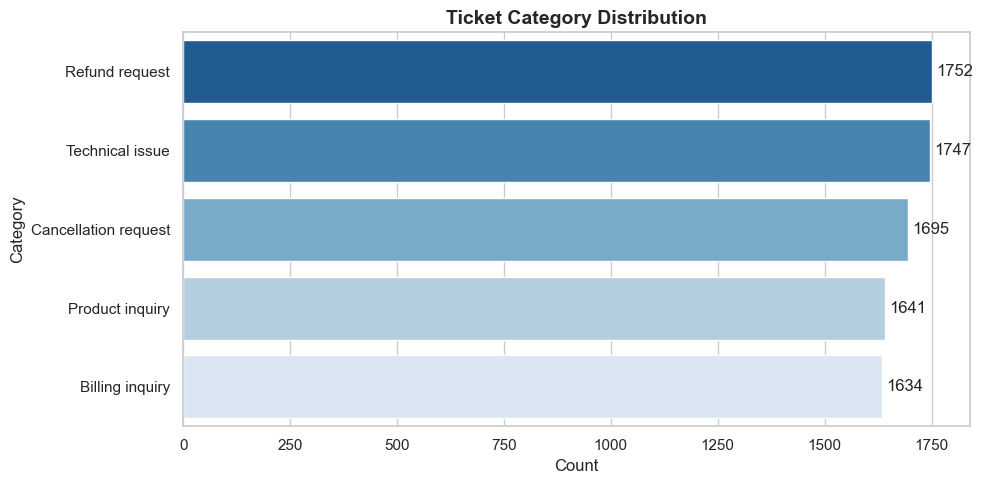

In [4]:
fig, ax = plt.subplots()

category_counts = df[CATEGORY_TARGET].value_counts()

sns.barplot(
    x=category_counts.values,
    y=category_counts.index,
    ax=ax,
    palette="Blues_r"
)

ax.set_title("Ticket Category Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Count")
ax.set_ylabel("Category")

for i, val in enumerate(category_counts.values):
    ax.text(val + 10, i, str(val), va="center")

plt.tight_layout()
plt.savefig("../outputs/figures/category_distribution.png", dpi=150)
plt.show()

C:\Users\jonah\AppData\Local\Temp\ipykernel_13140\1301777959.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


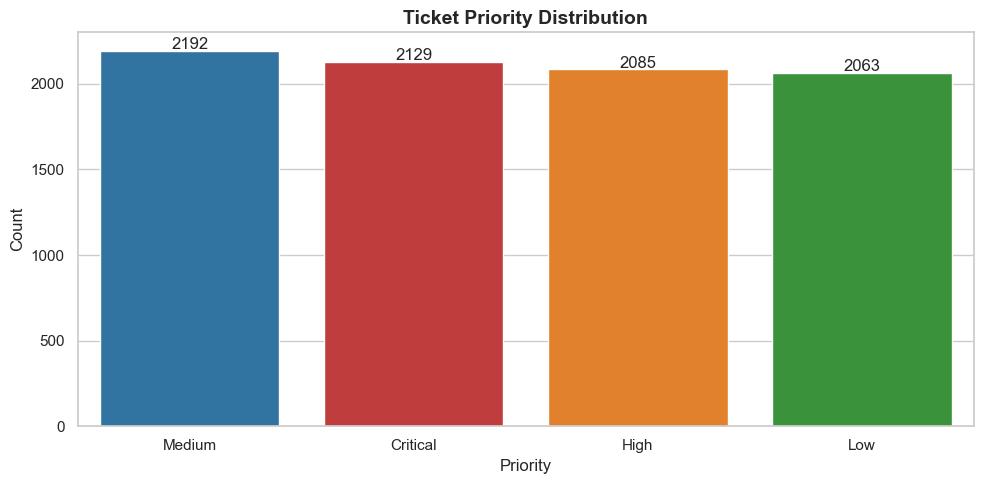

In [5]:
fig, ax = plt.subplots()

priority_counts = df[PRIORITY_TARGET].value_counts()

colors = {
    "Critical": "#d62728",
    "High":     "#ff7f0e", 
    "Medium":   "#1f77b4",
    "Low":      "#2ca02c"
}

palette = [colors.get(p, "#999999") for p in priority_counts.index]

sns.barplot(
    x=priority_counts.index,
    y=priority_counts.values,
    ax=ax,
    palette=palette
)

ax.set_title("Ticket Priority Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Priority")
ax.set_ylabel("Count")

for i, val in enumerate(priority_counts.values):
    ax.text(i, val + 10, str(val), ha="center")

plt.tight_layout()
plt.savefig("../outputs/figures/priority_distribution.png", dpi=150)
plt.show()

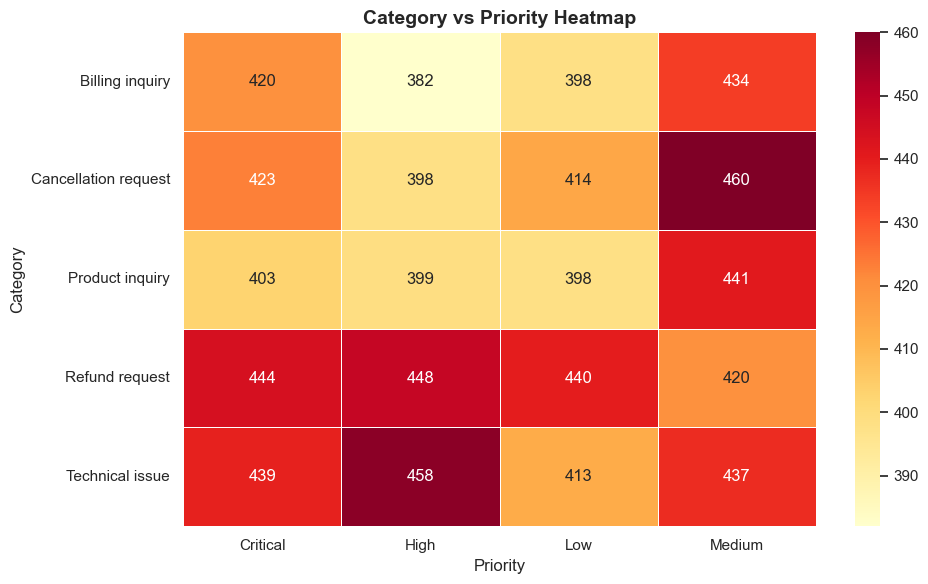

In [6]:
cross_tab = pd.crosstab(
    df[CATEGORY_TARGET],
    df[PRIORITY_TARGET]
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(
    cross_tab,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    ax=ax,
    linewidths=0.5
)

ax.set_title("Category vs Priority Heatmap", fontsize=14, fontweight="bold")
ax.set_xlabel("Priority")
ax.set_ylabel("Category")

plt.tight_layout()
plt.savefig("../outputs/figures/category_priority_heatmap.png", dpi=150)
plt.show()

In [9]:
key_cols = [TEXT_COLUMN, CATEGORY_TARGET, PRIORITY_TARGET]

print("=== Missing Values in Key Columns ===")
for col in key_cols:
    missing = df[col].isnull().sum()
    pct = (missing / len(df)) * 100
    print(f"{col:30s}: {missing} missing ({pct:.1f}%)")

=== Missing Values in Key Columns ===
Ticket Description            : 0 missing (0.0%)
Ticket Type                   : 0 missing (0.0%)
Ticket Priority               : 0 missing (0.0%)


C:\Users\jonah\AppData\Local\Temp\ipykernel_13140\688674823.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


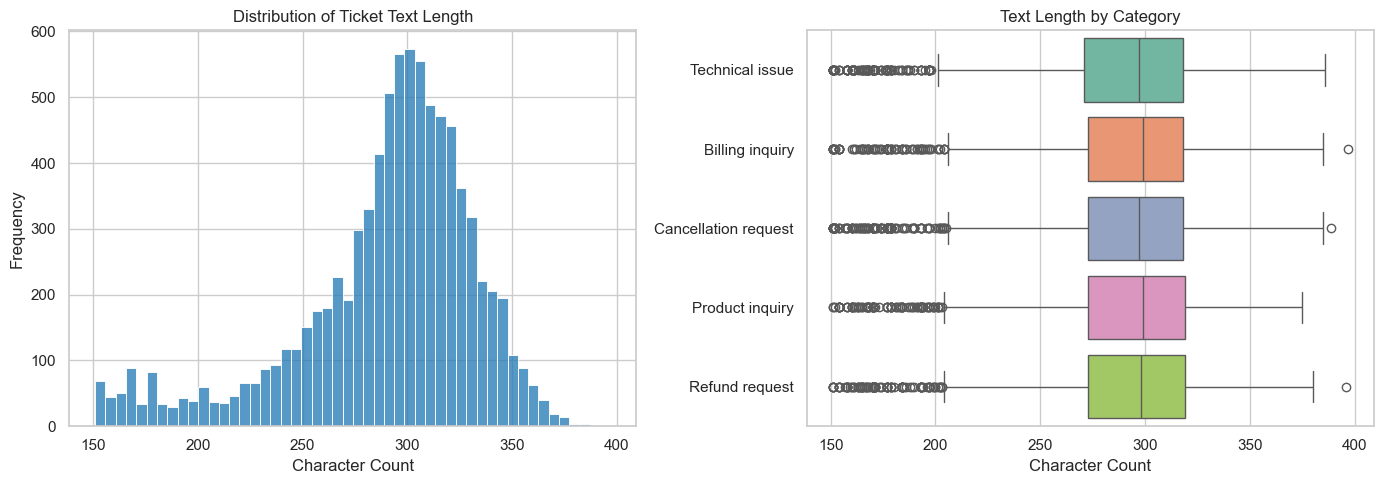

count    8469.000000
mean      289.821939
std        43.593954
min       151.000000
25%       273.000000
50%       298.000000
75%       318.000000
max       397.000000
Name: text_length, dtype: float64


In [8]:
df["text_length"] = df[TEXT_COLUMN].astype(str).apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sns.histplot(df["text_length"], bins=50, ax=axes[0], color="#1f77b4")
axes[0].set_title("Distribution of Ticket Text Length")
axes[0].set_xlabel("Character Count")
axes[0].set_ylabel("Frequency")

# Boxplot by category
sns.boxplot(
    data=df,
    x="text_length",
    y=CATEGORY_TARGET,
    ax=axes[1],
    palette="Set2"
)
axes[1].set_title("Text Length by Category")
axes[1].set_xlabel("Character Count")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("../outputs/figures/text_length_analysis.png", dpi=150)
plt.show()

print(df["text_length"].describe())

In [10]:
print("=== DATASET SUMMARY ===")
print(f"Total tickets:      {len(df)}")
print(f"Unique categories:  {df[CATEGORY_TARGET].nunique()}")
print(f"Unique priorities:  {df[PRIORITY_TARGET].nunique()}")
print(f"Avg text length:    {df['text_length'].mean():.0f} characters")
print(f"\nCategories: {df[CATEGORY_TARGET].unique().tolist()}")
print(f"Priorities:  {df[PRIORITY_TARGET].unique().tolist()}")

=== DATASET SUMMARY ===
Total tickets:      8469
Unique categories:  5
Unique priorities:  4
Avg text length:    290 characters

Categories: ['Technical issue', 'Billing inquiry', 'Cancellation request', 'Product inquiry', 'Refund request']
Priorities:  ['Critical', 'Low', 'High', 'Medium']


In [11]:
print("=== CLASS BALANCE CHECK ===")
print("\nCategory counts:")
print(df[CATEGORY_TARGET].value_counts())
print("\nPriority counts:")
print(df[PRIORITY_TARGET].value_counts())


=== CLASS BALANCE CHECK ===

Category counts:
Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

Priority counts:
Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64
